# Titanic survival prediction

In [68]:
#EDA and preprocessing and feature engineering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data acquisition

In [69]:
#load the training dataset and the test dataset
train_set = pd.read_csv("data/train.csv")
test_set = pd.read_csv("data/test.csv")

### Data discovering and preprocessing

In [70]:
print("shape of the training dataset :",train_set.shape)
print("list of features : ",train_set.columns.tolist())

shape of the training dataset : (891, 12)
list of features :  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [71]:
#EDA
##Data structure inspection
print(train_set.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [72]:
print(train_set.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [73]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [74]:
train_set.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [75]:
train_set.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [76]:
print(train_set.duplicated().sum())
#there is no duplicates

0


In [77]:
print("Is every sample in the dataset is unique :",train_set.index.is_unique)

print(train_set.nunique())

Is every sample in the dataset is unique : True
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


In [78]:
missing = train_set.isnull().mean().sort_values(ascending = False)
print(missing)

Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
dtype: float64


In [79]:
missing = missing[missing > 0]
print(missing)

Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64


In [ ]:
# 77% of the passagers have a missing value for the feature Cabin, it looks very convenient to drop this feature.
train_set.drop(columns=['Cabin'], inplace=True)

# 19% of the passagers have a missing value for the feature Age. The percentage is quite high but we may think that it is an important feature
# We replace the missing values by the mean age
train_set["Age"] = train_set["Age"].fillna(train_set["Age"].median())

# Only 2% of passagers have a missing value in Embarked
train_set["Embarked"] = train_set["Embarked"].fillna(train_set["Embarked"].mode()[0])


In [81]:
missing = train_set.isnull().mean().sort_values(ascending = False)
missing = missing[missing > 0]
print(missing)


Series([], dtype: float64)


In [82]:
#Get rid of constant features
train_set = train_set.loc[ : , train_set.apply(pd.Series.nunique) != 1]

In [83]:
## Inspecting the type object features
print(train_set["Embarked"].unique())
print("-----------------------")
print(train_set["Embarked"].value_counts(dropna = False))

['S' 'C' 'Q']
-----------------------
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


### EDA

#### Univariate analysis : 


In [ ]:
#Unvariate analysis

## We separate categorical and numerical features because univariate analysis is done differently for both of them
## Numerical columns
num_cols = ['Age','Fare']

## Categorical columns
cat_cols = ['Pclass','SibSp', 'Parch','Embarked','Sex']

print('num_cols : ',num_cols)
print('cat_cols : ',cat_cols)

num_cols :  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
cat_cols :  Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')


In [ ]:
print("Age mean : ",train_set['Age'].mean())
print("Age std : ",train_set['Age'].std())
print("Age median : ",train_set["Age"].quantile(0.5))
print("Age skew : ",train_set['Age'].skew())
## the skew is very low.The Age graph is very symmetric 


Age mean :  29.69911764705882
Age std :  13.002015226002884
Age median :  29.69911764705882
Age skew :  0.4344880940129925


In [143]:
train_set["Age"].describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

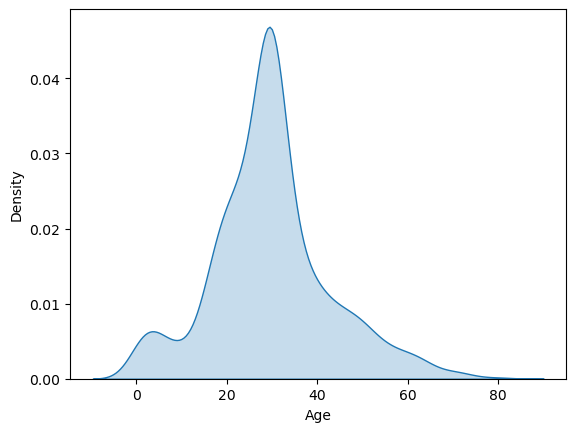

In [103]:
sns.kdeplot(train_set['Age'], fill=True)

<Axes: ylabel='Age'>

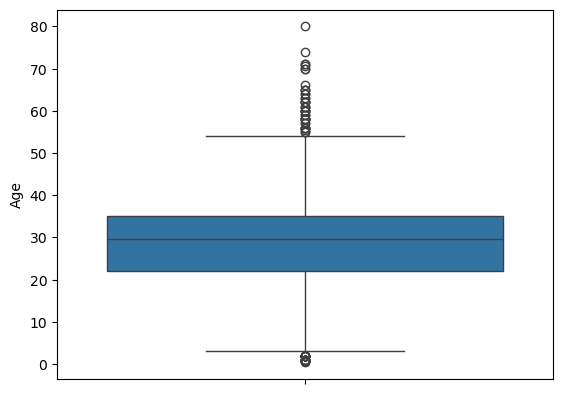

In [142]:
#Boxplot
sns.boxplot(data=train_set["Age"])

In [ ]:
## As we have seen before, approximately 20% of Age values are missing. We will will replace those values by the median value of this column. 
## One can ask why the median and not the mean. The median is more suited because the distribution of Age is lightly skewed (driven by some outliers that are old people on board) 
# to the right so the mean gives a slightly wrong impression about the Age.

<Axes: xlabel='Age'>

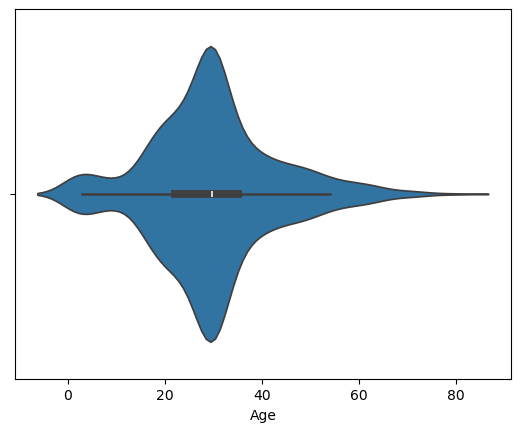

In [145]:
sns.violinplot(x=train_set['Age'])

In [ ]:
sns.violinplot(x=df['Age'])

<Axes: xlabel='Fare', ylabel='Density'>

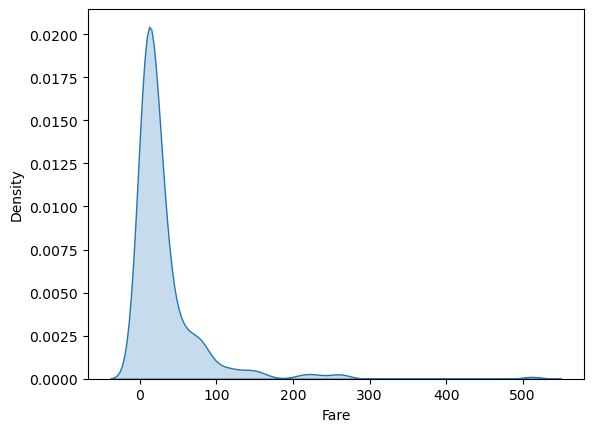

In [122]:
sns.kdeplot(train_set["Fare"], fill=True)

In [ ]:
print("Fare mean : ",train_set["Fare"].mean())
print("Fare std : ",train_set["Fare"].std())
print("Fare median : ",train_set["Fare"].quantile(0.5))
print("Fare skew : ",train_set["Fare"].skew())

## We can see clearly that the skew of fare is huge. This could be explained by the fact that most passengers were from the third class, hence their fare were low.

Fare mean :  32.204207968574636
Fare std :  49.693428597180905
Fare median :  14.4542
Fare skew :  4.787316519674893


<Axes: xlabel='SibSp', ylabel='Percent'>

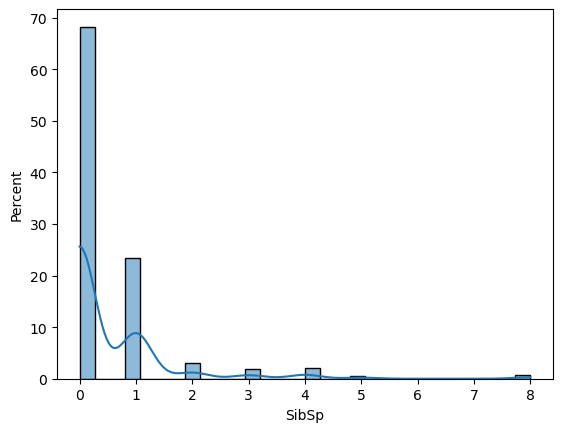

In [ ]:
sns.histplot(train_set["SibSp"], kde=True, bins=30, stat="percent")
## Most people on the titanic were without spouses and siblings (approximately 68%)

<Axes: xlabel='Parch', ylabel='Percent'>

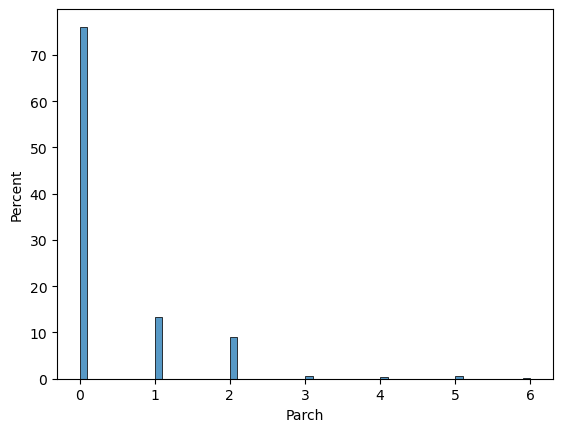

In [ ]:
train_set['Parch'].value_counts()
sns.histplot(train_set["Parch"], stat="percent")
## Most people on the titanic were without chidren or parents

<Axes: xlabel='Sex', ylabel='Percent'>

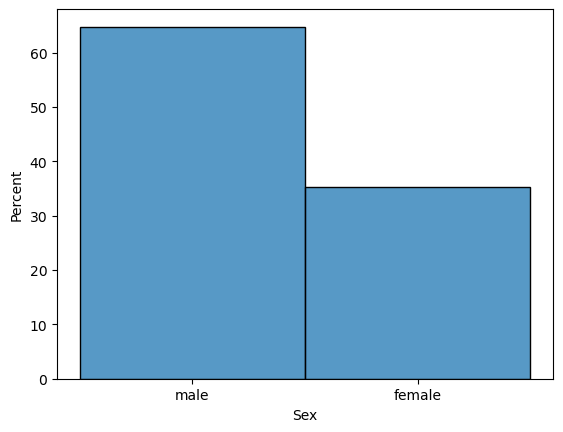

In [ ]:
sns.histplot(train_set["Sex"], kde=False, bins=30, stat="percent")
## Most of the passengers were male (more then 60%). 

<Axes: xlabel='Embarked', ylabel='Percent'>

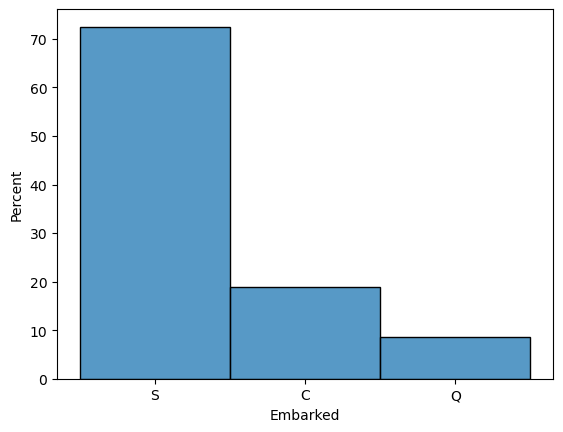

In [ ]:
sns.histplot(train_set["Embarked"], kde=False, stat="percent")
## Embarked is a categorical feature indicating the port where a passenger boarded the ship.
## We observe that most passengers boarded in S. 

<Axes: ylabel='Fare'>

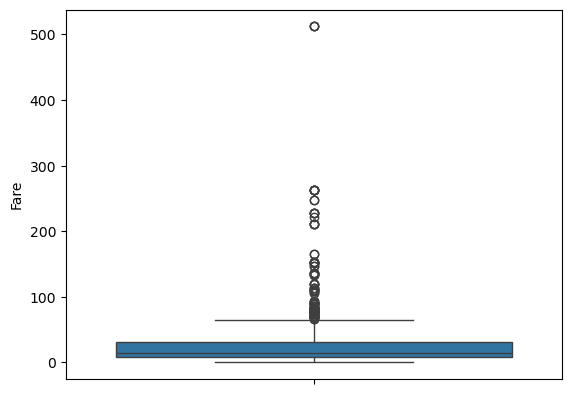

In [144]:
sns.boxplot(data=train_set["Fare"])

<Axes: xlabel='Survived', ylabel='Percent'>

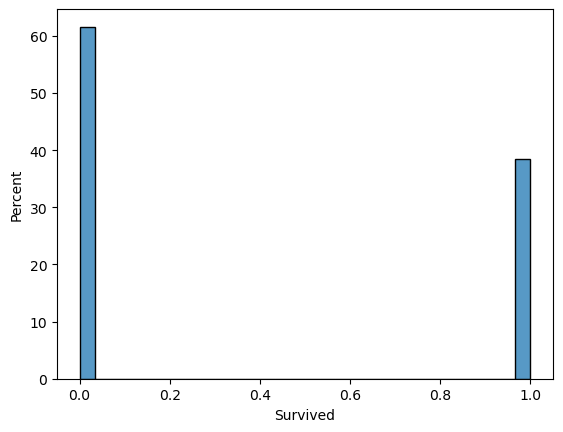

In [141]:
sns.histplot(train_set["Survived"], kde=False, bins=30, stat="percent")
## Survived is the target feature. We can see that the two classes are balanced (60% for balanced and 40% for balanced)

## Bivariate analysis

In [95]:
### Outlier detection using IQR
for col in num_cols :
    q1 = train_set[col].quantile(0.25)
    q3 = train_set[col].quantile(0.75)
    iqr = q3 - q1
    outliers = train_set[(train_set < q1 - 1.5*iqr) | (train_set > q3 - 1.5*iqr)]
    print(f'number of outliers for {col} is {len(outliers)}')
    

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

In [ ]:
# Bivariate analysis
## Numerical features
for col in cat_cols :
    sns.boxplot(x=train_set['target'], y=train_set[col])
    plt.title(f"{col} vs target")
    plt.show()

In [ ]:
## Categorical features
for col in cat_cols :
    ct = pd.crosstab(train_set[col], train_set['S'], normalize='index')
    print(ct)
    ct.plot(kind='bar', stacked=True)
    plt.title(f'{col} vs target')
    plt.show()

KeyError: 'target'

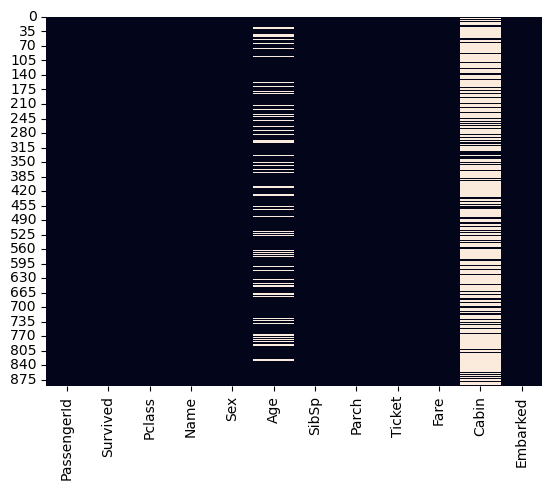

In [ ]:
sns.heatmap(train_set.isnull(), cbar=False)
plt.show()

In [ ]:
train_set.describe(percentiles=[0.01, 0.99]).T

,count,mean,std,min,1%,50%,99%,max
PassengerId,891.0,446.000000,257.353842,1.00,9.9,446.0000,882.10000,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0,0.0000,1.00000,1.0000
Pclass,891.0,2.308642,0.836071,1.00,1.0,3.0000,3.00000,3.0000
Age,714.0,29.699118,14.526497,0.42,1.0,28.0000,65.87000,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0,0.0000,5.00000,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0,0.0000,4.00000,6.0000
Fare,891.0,32.204208,49.693429,0.00,0.0,14.4542,249.00622,512.3292


In [ ]:
def iqr_outliers(series) :
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    print(q1 - 1.5*iqr)
    print(q3 + 1.5*iqr)
    print(q3)
    return series[(series < q1 -1.5*iqr) | (series > q3 + 1.5*iqr)]

outliers = iqr_outliers(train_set['Age'])
print(len(outliers)/train_set.shape[0])


-6.6875
64.8125
38.0
0.012345679012345678


<Axes: >

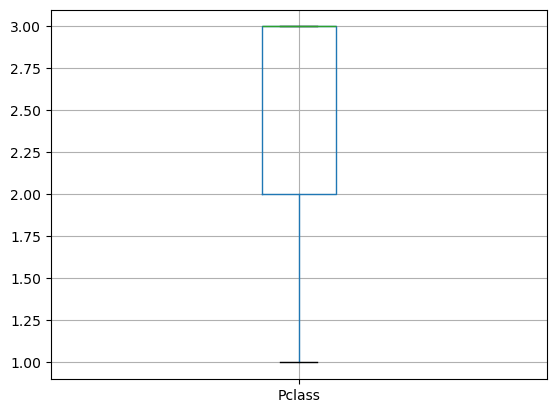

In [ ]:
train_set.boxplot(column='Pclass')

In [ ]:
train_set[['Pclass']].boxplot()

In [ ]:
#Preprocessing


In [ ]:
#Feature engineering

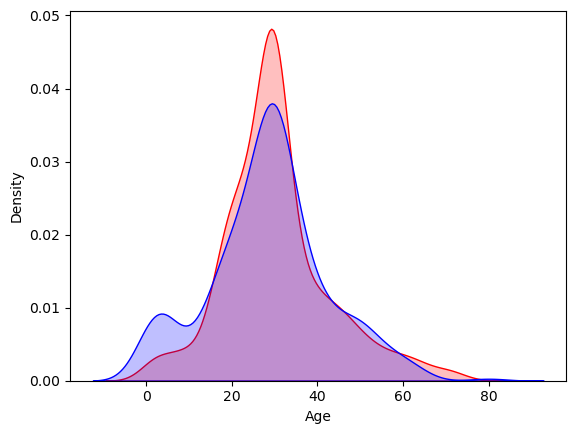

In [ ]:
plot = sns.kdeplot(train_set.loc[train_set["Survived"]==0].Age, color='red', fill=True)
plot = sns.kdeplot(train_set.Age[(train_set["Survived"]==1)], color='blue', fill=True)


In [ ]:
corr_matrix = train_set[num_cols].corr()
print(corr_matrix.index.tolist())
print(corr_matrix.columns.tolist())
# corr_matrix["Pclass"].sort_values(ascending=False).plot(kind='bar')
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# corr_matrix["Pclass"].sort_values(ascending=False).plot(kind='bar')
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


<Axes: xlabel='Age'>

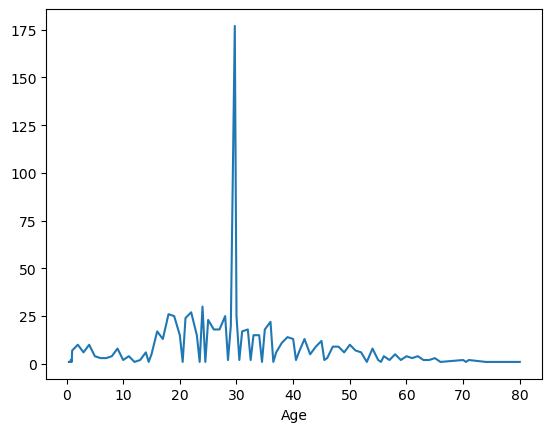

In [ ]:
train_set["Age"].value_counts().sort_index(ascending=True).plot()

In [ ]:
pd.crosstab(train_set[])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3783860150.py, line 1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform((X_train))
X_test_scaled = scaler.fit_transform(X_test)


### Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metric import classification_report, roc_auc_score

#-------- separate features and target
X = train_set.drop(columns = ['Survived'])
y = train_set['Survived']

#-------- train/validation split
X_train, y_train, X_val, y_val = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42 
)


model = Pipeline(steps = [
                        ("scaler", StandardScaler()), 
                        ("clf",LogisticRegression(
                            max_iter=1000,
                            class_weight="balanced",
                            random_state=42))
])


model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC AUC :",roc_auc_score(y_val, y_proba))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    m_enstimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=1
)

model.fit(X_train, y_train)
y_pred = model.predict(y_val)


In [ ]:
import optuna

def objective(trial) :
    params = {
        "n_estimators" : trial.suggest_int("n_estimators" : 100, 600),
        "max_depth" : trial.suggest_int("max_depth" : 3, 20),
        "min_samples_split" : trial.suggest_int("min_samples_split" : 2, 200),
        "min_samples_leaf" : trial.suggest_int("min_samples_leaf" : 2, 23),
        "max_features" : trial.suggest_categorical("max_features" : 2, 30),
        "random_state" : 42,
        "n_jobs" : -1
    }

    model = RandomForestClassifier(** params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score





In [ ]:
from sklearn.preprocessing import MinMaxScaler

df = pd.DataFrame(train_set, columns=['Age', 'Fare'])
scaler = MinMaxScaler()
scaled_value = scaler.fit_transform(df)
scaled_value.head()

NameError: name 'train_set' is not defined

In [ ]:
scaler = StandardScaler()

import statistics as st
import statistics as st


In [ ]:
# Funtion to detect outliers using the 

### Model evaluation

### Deployment